In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from mad.configs import sputnik_stages, sputnik, titan2_stages
from mad.configs.planets import EARTH_SETTINGS
from mad.objs import Planet, PlanetConfig
from mad.objs import BallisticMissileConfig, MissileStage, MissileStageConfig, BallisticMissile, SatelliteConfig, Sputnik
from mad.guidances import NoGuidance, LEOInsertionGuidance
from mad.simulation import Simulation
from mad.logger import SourceLogger

logger = SourceLogger()

In [3]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

launchsite_target_distance_km = 1000
earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = earth.create_2D_point(name="Launchpad", altitude=10)
target = earth.create_2D_point_at_distance(launchpad, distance_km=launchsite_target_distance_km, name="Target")

In [8]:
missile_stages = [MissileStage(MissileStageConfig(**stage_cfg)) for stage_cfg in sputnik_stages]

missile_guidance = LEOInsertionGuidance(planet=earth, 
                                        target_altitude_m = 180_000,
                                        target=target,
                                        min_turn_altitude_m=0,
                                        turn_end_altitude_m=100_000,)


payload_cfg = SatelliteConfig(**sputnik)

missile_cfg = BallisticMissileConfig(stages=missile_stages, 
                                     guidance=missile_guidance, 
                                     payload=payload_cfg, 
                                     n_payloads = 1, 
                                     payload_separation_interval=5.0)
semyorka = BallisticMissile(position=launchpad.position.copy(), cfg=missile_cfg, name="Semyorka")

semyorka


BallisticMissile Semyorka, active.
Stages: Bloc_BVGD, Bloc_A.
Available deltaV: 9367.08 m/s.
Guidance: LEOInsertionGuidance.
Payloads: Sputnik.

In [9]:
dt = 0.5
max_time = 2_000.

sim = Simulation(max_time=max_time, dt=dt)
sim.run(
    planet=earth,
    moving_objs=[semyorka],
)

df = sim.results

22:17:33 | INFO     | Simulation   | Starting simulation.
22:17:33 | INFO     | Missile      | Bloc_BVGD ran out of propellant at 70.50.
22:17:33 | INFO     | Missile      | Semyorka - Bloc_BVGD separated at 70.50.
22:17:33 | INFO     | Simulation   | New objects spawned this step: ['Bloc_BVGD']
22:17:33 | INFO     | Missile      | Bloc_A ran out of propellant at 298.00.
22:17:33 | INFO     | Missile      | Semyorka - Bloc_A separated at 298.00.
22:17:33 | INFO     | Missile      | Semyorka entering coast phase at 298.00.
22:17:33 | INFO     | Simulation   | New objects spawned this step: ['Bloc_A']
22:17:33 | INFO     | Guidance     | All propellant spent at altitude 97.1 km, v_horiz = 7435.7 m/s (target 7800.1 m/s). Releasing payload.
22:17:33 | INFO     | Missile      | Semyorka released payload Sputnik_1 at 298.50.
22:17:33 | INFO     | Missile      | Semyorka has released all payloads at 298.50. Stages deactivated.
22:17:33 | INFO     | Simulation   | New objects spawned this step

In [10]:
df["altitude_km"] = df["position"].apply(lambda pos: (np.linalg.norm(pos) - earth.radius) / 1e3)
df["energy_kJ"] = df["speed"].apply(lambda speed: 0.5 * speed**2 / 1e3)
df["gamma_deg"] = df["gamma"].apply(lambda g: np.degrees(g) if g is not None else None)
df = df.sort_values(by=["name", "time"])

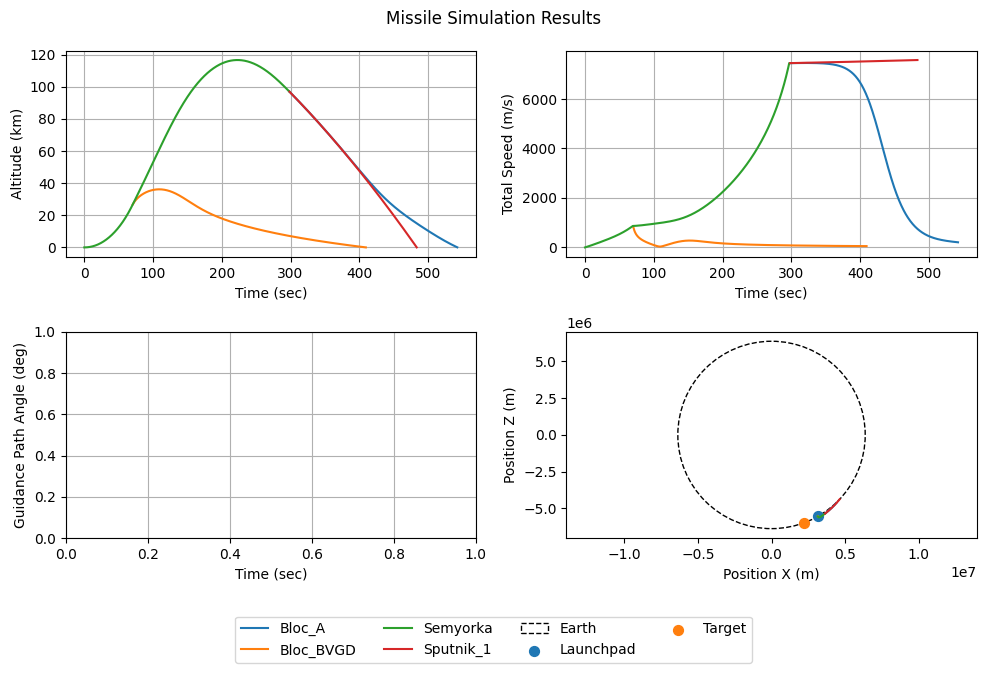

In [11]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 6))
ax = ax.ravel()

sns.lineplot(data=df, x="time", y="altitude_km", hue="name", ax=ax[0], )
sns.lineplot(data=df, x="time", y="speed", hue="name", ax=ax[1])
sns.lineplot(data=df, x="time", y="gamma_deg", hue="name", ax=ax[2])
sns.lineplot(data=df, x="posx", y="posz", hue="name", ax=ax[3])

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")

ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Guidance Path Angle (deg)")

earth.plot_2D_with_points(points = [launchpad, target], ax=ax[3], display="planet")
ax[3].set_xlabel("Position X (m)")
ax[3].set_ylabel("Position Z (m)")
ax[3].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()
    handles, labels = a.get_legend_handles_labels()
    a.legend().remove()

fig.suptitle("Missile Simulation Results")
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(pad=1.2)

In [22]:

# Diagnostics: re-run simulation and print guidance state at each second
from mad.configs import sputnik_stages, sputnik
from mad.objs import BallisticMissileConfig, MissileStage, MissileStageConfig, BallisticMissile, SatelliteConfig
from mad.guidances import LEOInsertionGuidance

missile_stages2 = [MissileStage(MissileStageConfig(**s)) for s in sputnik_stages]
missile_guidance2 = LEOInsertionGuidance(planet=earth, target_altitude_m=200_000, target=target)
payload_cfg2 = SatelliteConfig(**sputnik)
missile_cfg2 = BallisticMissileConfig(stages=missile_stages2, guidance=missile_guidance2, payload=payload_cfg2, n_payloads=1)
probe = BallisticMissile(position=launchpad.position.copy(), cfg=missile_cfg2, name="Probe")

sim2 = Simulation(max_time=2000.0, dt=1.0)
sim2.run(planet=earth, moving_objs=[probe])

df2 = sim2.results
df2["altitude_km"] = df2["position"].apply(lambda p: (np.linalg.norm(p) - earth.radius) / 1e3)
df2["v_horiz"] = df2.apply(
    lambda row: abs(np.dot(row["velocity"], target.normalize - np.dot(target.normalize, row["position"] / np.linalg.norm(row["position"])) * (row["position"] / np.linalg.norm(row["position"])))),
    axis=1
)
v_circ = np.sqrt(earth.mu / (earth.radius + 200_000))
print(f"v_circ at 200km = {v_circ:.1f} m/s, 99% = {0.99*v_circ:.1f} m/s")
print(f"Objects in sim: {df2['name'].unique()}")
probe_df = df2[df2["name"] == "Probe"]
print(f"\nProbe max altitude: {probe_df['altitude_km'].max():.1f} km at t={probe_df.loc[probe_df['altitude_km'].idxmax(), 'time']:.0f}s")
print(f"Probe max speed:    {probe_df['speed'].max():.0f} m/s")
print(f"Probe time range:   {probe_df['time'].min():.0f} - {probe_df['time'].max():.0f}s")
print(f"\nGuidance state samples (every 50s):")
for _, row in probe_df[probe_df["time"] % 50 == 0].iterrows():
    print(f"  t={row['time']:6.0f}s  alt={row['altitude_km']:7.1f}km  speed={row['speed']:7.0f}m/s")


15:54:30 | INFO     | Simulation   | Starting simulation.
15:54:30 | INFO     | Missile      | Bloc_BVGD ran out of propellant at 64.00.
15:54:30 | INFO     | Missile      | Probe - Bloc_BVGD separated at 64.00.
15:54:30 | INFO     | Simulation   | New objects spawned this step: ['Bloc_BVGD']
15:54:30 | INFO     | Projectile   | Bloc_BVGD landed on the ground!
15:54:30 | INFO     | Missile      | Bloc_A ran out of propellant at 335.00.
15:54:30 | INFO     | Missile      | Probe - Bloc_A separated at 335.00.
15:54:30 | INFO     | Missile      | Probe entering coast phase at 335.00.
15:54:30 | INFO     | Simulation   | New objects spawned this step: ['Bloc_A']
15:54:31 | INFO     | Projectile   | Bloc_A landed on the ground!
15:54:31 | INFO     | Simulation   | Simulation ended at 2000.00s. Took 0.49 s of real time.
v_circ at 200km = 7788.2 m/s, 99% = 7710.4 m/s
Objects in sim: <StringArray>
['Probe', 'Bloc_BVGD', 'Bloc_A']
Length: 3, dtype: str

Probe max altitude: 371.1 km at t=577s
Pr